<a href="https://colab.research.google.com/github/wwx0015/CDS524-Assignment-1/blob/main/CDS524_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import random

# ==========================================
# 1. 游戏环境定义 (Game Environment)
# 对应评分点: 1.1, 1.2, 1.3
# ==========================================
class GridWorld:
    def __init__(self):
        self.grid_size = 5 # 5x5 网格 (State Space)
        self.start_state = (0, 0) # 起点左上角
        self.goal_state = (4, 4)  # 宝藏右下角
        self.traps = [(1, 2), (3, 3)] # 陷阱位置
        self.obstacles = [(2, 2)]     # 墙壁/障碍物位置

        # 动作空间 (Action Space): 0:上, 1:下, 2:左, 3:右
        self.action_space = [0, 1, 2, 3]
        self.state = self.start_state

    def reset(self):
        """重置游戏到初始状态 / Reset the environment to start state"""
        self.state = self.start_state
        return self.state

    def step(self, action):
        """
        执行动作并返回: 下一个状态, 奖励, 是否结束
        Take an action and return: next_state, reward, done
        """
        x, y = self.state
        next_x, next_y = x, y

        # 根据动作计算下一个位置
        if action == 0:   # 上 Up
            next_x -= 1
        elif action == 1: # 下 Down
            next_x += 1
        elif action == 2: # 左 Left
            next_y -= 1
        elif action == 3: # 右 Right
            next_y += 1

        # 检查是否撞墙或超出边界 (Boundary & Obstacle Check)
        if (next_x < 0 or next_x >= self.grid_size or
            next_y < 0 or next_y >= self.grid_size or
            (next_x, next_y) in self.obstacles):
            # 撞墙惩罚，状态不变
            return self.state, -10, False

        # 更新状态
        self.state = (next_x, next_y)

        # 计算奖励 (Reward Function)
        if self.state == self.goal_state:
            return self.state, 100, True   # 找到宝藏: +100，游戏结束
        elif self.state in self.traps:
            return self.state, -100, True  # 掉入陷阱: -100，游戏结束
        else:
            return self.state, -1, False   # 普通移动: -1，鼓励寻找最短路径

# ==========================================
# 2. Q-Learning 智能体定义 (Q-Learning Agent)
# 对应评分点: 2.1, 2.2, 2.3
# ==========================================
class QLearningAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions
        self.alpha = alpha       # 学习率 Learning Rate
        self.gamma = gamma       # 折扣因子 Discount Factor
        self.epsilon = epsilon   # 探索率 Epsilon for epsilon-greedy
        self.q_table = {}        # Q表 Q-Table

    def get_q_value(self, state, action):
        """获取 Q 值，如果状态不存在则初始化为 0.0"""
        if state not in self.q_table:
            self.q_table[state] = {a: 0.0 for a in self.actions}
        return self.q_table[state][action]

    def choose_action(self, state):
        """Epsilon-greedy 策略选择动作"""
        if state not in self.q_table:
            self.q_table[state] = {a: 0.0 for a in self.actions}

        # 探索 (Exploration): 以 epsilon 的概率随机选择动作
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)

        # 利用 (Exploitation): 选择当前 Q 值最大的动作
        max_q = max(self.q_table[state].values())
        # 如果有多个最大值，随机挑一个（打破平局）
        best_actions = [a for a in self.actions if self.q_table[state][a] == max_q]
        return random.choice(best_actions)

    def learn(self, state, action, reward, next_state):
        """
        Q-Learning 核心更新公式
        Q(S, A) <- Q(S, A) + alpha * [R + gamma * max(Q(S', a)) - Q(S, A)]
        """
        current_q = self.get_q_value(state, action)

        if next_state not in self.q_table:
             self.q_table[next_state] = {a: 0.0 for a in self.actions}

        max_next_q = max(self.q_table[next_state].values())

        # 更新 Q 值
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[state][action] = new_q

# ==========================================
# 3. 训练循环 (Training Loop)
# ==========================================
if __name__ == "__main__":
    env = GridWorld()
    agent = QLearningAgent(actions=env.action_space, alpha=0.1, gamma=0.9, epsilon=0.2)

    episodes = 500 # 训练回合数
    rewards_history = [] # 记录每回合的总奖励，方便写报告时画图评估

    print("开始训练 (Training started)...")
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False

        # 随着训练进行，逐渐减少探索率 (Epsilon Decay)
        # 这会让 AI 在后期更倾向于使用学到的最优路径
        agent.epsilon = max(0.01, agent.epsilon * 0.99)

        while not done:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.learn(state, action, reward, next_state)

            state = next_state
            total_reward += reward

        rewards_history.append(total_reward)

        # 每 100 回合打印一次进度
        if (episode + 1) % 100 == 0:
            print(f"Episode: {episode + 1}, Last Reward: {total_reward}, Epsilon: {agent.epsilon:.4f}")

    print("训练完成! (Training finished!)")

    # 测试一下训练成果
    print("\n--- 测试最优路径 (Testing Optimal Path) ---")
    state = env.reset()
    done = False
    step_count = 0
    agent.epsilon = 0.0 # 测试时关闭探索，完全利用学到的 Q 表

    path = [state]
    while not done and step_count < 20: # 防止死循环死锁
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        path.append(next_state)
        state = next_state
        step_count += 1

    print(f"智能体行进路线: {path}")
    if state == env.goal_state:
        print("✅ 成功到达终点！")
    else:
        print("❌ 未能到达终点 (掉入陷阱或超时)。")

开始训练 (Training started)...
Episode: 100, Last Reward: 93, Epsilon: 0.0732
Episode: 200, Last Reward: 93, Epsilon: 0.0268
Episode: 300, Last Reward: 93, Epsilon: 0.0100
Episode: 400, Last Reward: 93, Epsilon: 0.0100
Episode: 500, Last Reward: 93, Epsilon: 0.0100
训练完成! (Training finished!)

--- 测试最优路径 (Testing Optimal Path) ---
智能体行进路线: [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (4, 1), (4, 2), (4, 3), (4, 4)]
✅ 成功到达终点！


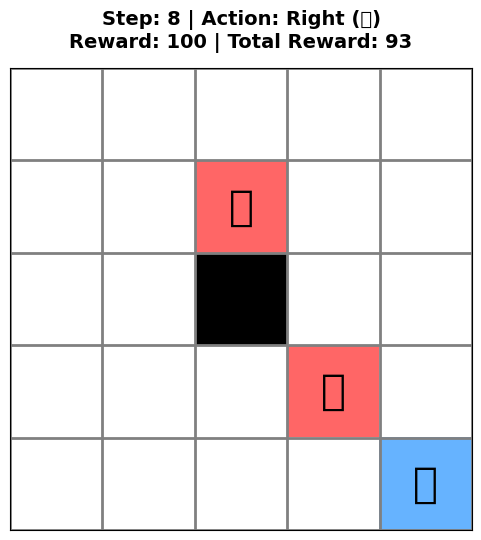


🎉 演示结束：智能体成功找到最短路径并获取宝藏！


In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import clear_output
import time

# ==========================================
# UI 渲染函数 (满足 Rubric 3.1 & 3.2)
# ==========================================
def render_grid(env, step_num, action_taken, last_reward, total_reward):
    """
    动态渲染网格世界 / Render the grid world dynamically
    """
    # 清除上一步的输出，实现动画效果
    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(6, 6))

    # 创建 5x5 矩阵，初始化为 0 (空白)
    grid = np.zeros((env.grid_size, env.grid_size))

    # 标记不同元素的状态码
    for obs in env.obstacles:
        grid[obs] = 1 # 墙壁
    for trap in env.traps:
        grid[trap] = 2 # 陷阱
    grid[env.goal_state] = 3 # 宝藏
    grid[env.state] = 4 # 智能体 (Agent)

    # 自定义颜色映射 (Colormap): 空白-白, 墙-黑, 陷阱-红, 宝藏-金, 智能体-蓝
    cmap = mcolors.ListedColormap(['white', 'black', '#ff6666', '#ffd700', '#66b3ff'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # 绘制基础颜色网格
    ax.imshow(grid, cmap=cmap, norm=norm)

    # 绘制网格线
    ax.set_xticks(np.arange(-.5, env.grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-.5, env.grid_size, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xticks([]) # 隐藏坐标轴数字
    ax.set_yticks([])

    # 添加 Emoji 图标以增强直观性 (User Experience)
    for x in range(env.grid_size):
        for y in range(env.grid_size):
            if (x, y) == env.state:
                ax.text(y, x, '🤖', ha='center', va='center', fontsize=30)
            elif (x, y) == env.goal_state:
                ax.text(y, x, '💰', ha='center', va='center', fontsize=30)
            elif (x, y) in env.traps:
                ax.text(y, x, '🔥', ha='center', va='center', fontsize=30)
            elif (x, y) in env.obstacles:
                ax.text(y, x, '🧱', ha='center', va='center', fontsize=30)

    # 动作名称映射表
    action_names = {0: "Up (上)", 1: "Down (下)", 2: "Left (左)", 3: "Right (右)", None: "Start (开始)"}
    act_str = action_names.get(action_taken, "Unknown")

    # 满足 Rubric 3.2: 标题栏实时显示状态、动作、奖励
    ax.set_title(f"Step: {step_num} | Action: {act_str}\n"
                 f"Reward: {last_reward} | Total Reward: {total_reward}",
                 fontsize=14, fontweight='bold', pad=15)

    plt.show()
    # 暂停 0.5 秒，让人眼能看清动画帧
    time.sleep(0.5)

# ==========================================
# 运行可视化演示 (Visual Demonstration)
# ==========================================
if __name__ == "__main__":
    print("开始播放训练后的最优路径动画...")
    time.sleep(2) # 给用户2秒钟准备看动画

    env.reset()
    done = False
    step_count = 0
    total_reward = 0
    last_reward = 0
    action = None

    # 测试时关闭探索 (Epsilon = 0)，完全使用学到的策略
    agent.epsilon = 0.0

    # 渲染初始画面
    render_grid(env, step_count, action, last_reward, total_reward)

    while not done and step_count < 20: # 限制最大步数防止死循环
        # 1. AI 决策
        action = agent.choose_action(env.state)
        # 2. 与环境交互
        next_state, reward, done = env.step(action)

        # 更新数据
        step_count += 1
        total_reward += reward
        last_reward = reward

        # 3. 渲染新画面
        render_grid(env, step_count, action, last_reward, total_reward)

    if env.state == env.goal_state:
        print("\n🎉 演示结束：智能体成功找到最短路径并获取宝藏！")
    else:
        print("\n❌ 演示结束：智能体未能到达终点。")